In [1]:
import sys, argparse
import pickle, json
import os

import numpy as np
import matplotlib.pyplot as plt
import glob


from defiant import OptimalStatistic
from defiant.extra import mdc1_utils
from la_forge.core import Core
import healpy as hp

import libstempo as T
import libstempo.plot as LP, libstempo.toasim as LT
import enterprise.signals.parameter as parameter
from enterprise.signals import white_signals
from enterprise.signals import utils
from enterprise.signals import gp_signals
from enterprise.signals import signal_base

from enterprise.pulsar import Pulsar, Tempo2Pulsar

import PTA_utils

from maps.anis_pta import anis_pta
from maps.utils import *

Optional mpi4py package is not installed.  MPI support is not available.


/home/nata/miniconda3/envs/ent15y/lib/python3.9/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


In [2]:
datapath = "./final"

par_dir = os.path.join(datapath, "par")

tim_dir = os.path.join(datapath, "tim")

parfiles = sorted(glob.glob(os.path.join(par_dir, "*.par")))

if len(parfiles) == 0:

    raise FileNotFoundError(f"No .par files found in {par_dir}")

psrs = []

for parfile in parfiles:

    name = os.path.splitext(os.path.basename(parfile))[0]

    timfile = os.path.join(tim_dir, name + ".tim")

    if not os.path.exists(timfile):

        print(f"Skipping {name}: no matching .tim file")

        continue

    print(f"Loading {name}")

    psr = T.tempopulsar(

        parfile=parfile,

        timfile=timfile,

    )

    psrs.append(psr)

Npsr = len(psrs)

if Npsr < 2:

    raise ValueError(f"Need at least 2 pulsars, loaded {Npsr}")

print(f"Loaded {Npsr} pulsars from {datapath}")

FileNotFoundError: No .par files found in psrE1/final/par

In [15]:
parfiles = sorted(glob.glob(os.path.join(datapath, "par", "*.par")))
timfiles = sorted(glob.glob(os.path.join(datapath, "tim", "*.tim")))

PSRs = []

for p, t in zip(parfiles, timfiles):
    psr = Pulsar(p, t)
    PSRs.append(psr)


#for psr in psrs:
#    PSRs.append(Tempo2Pulsar(psr))

#print(f"Converted {len(PSRs)} pulsars to enterprise Pulsar objects")

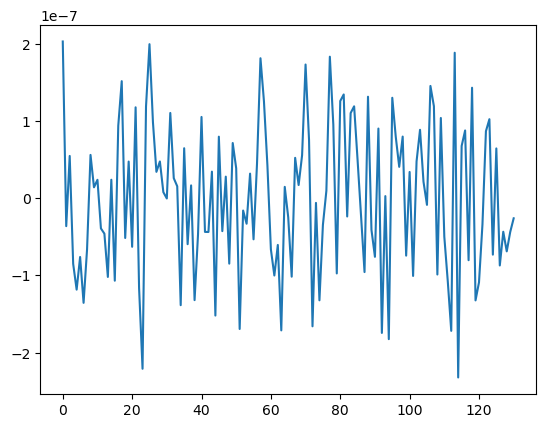

In [20]:
plt.plot(PSRs[3].residuals)

## Creating a dataset

## Building sky map from the OS results